# Data Preparation: UrbanSound8K

This notebook downloads and preveiws the dataset.  
According to the protocol, **we must not shuffle UrbanSound8K randomly**. The dataset provides 10 predefined folds. We will preserve those folds and later evaluate models with 10-folds-cross-validation.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path.cwd().parent.resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Raw data dir:", RAW_DIR)
print("Processed data dir:", PROCESSED_DIR)

Project root: D:\Projects\Audio\Audio Pattern Recognition
Raw data dir: D:\Projects\Audio\Audio Pattern Recognition\data\raw
Processed data dir: D:\Projects\Audio\Audio Pattern Recognition\data\processed


d:\Programs\anaconda3\envs\kaggle\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Downloading the Dataset

In [2]:
import soundata

dataset = soundata.initialize(
    "urbansound8k", data_home=str(RAW_DIR / "UrbanSound8K_soundata")
)

In [ ]:
dataset.download()

INFO: Downloading ['all', 'index']. Index is being stored in D:\Programs\anaconda3\envs\kaggle\Lib\site-packages\soundata\datasets\indexes, and the rest of files in D:\Projects\Audio\Audio Pattern Recognition\data\raw\UrbanSound8K_soundata
INFO: [all] downloading UrbanSound8K.tar.gz
5.61GB [07:40, 13.1MB/s]                                
INFO: [index] downloading urbansound8k_index_1.0.json
INFO: D:\Programs\anaconda3\envs\kaggle\Lib\site-packages\soundata\datasets\indexes\urbansound8k_index_1.0.json already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.


In [3]:
dataset.validate()

100%|██████████| 8732/8732 [01:24<00:00, 103.26it/s]
INFO: Success: the dataset is complete and all files are valid.
INFO: --------------------


({'metadata': {}, 'clips': {}}, {'metadata': {}, 'clips': {}})

## Loading Metadata

In [4]:
DATASET_DIR = RAW_DIR / "UrbanSound8K_soundata"
METADATA_DIR = DATASET_DIR / "metadata/UrbanSound8K.csv"


def load_metadata(metadata_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(metadata_dir)
    df["audio_path"] = df.apply(
        lambda row: str(
            DATASET_DIR / f"audio/fold{row['fold']}" / row["slice_file_name"]
        ),
        axis=1,
    )
    return df


metadata = load_metadata(METADATA_DIR)
print(metadata.shape)
display(metadata.head())

(8732, 9)


,slice_file_name,fsID,start,end,salience,fold,classID,class,audio_path
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,D:\Projects\Audio\Audio Pattern Recognition\da...
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...


## Basic Integrity Check

In [5]:
print("Number of clips:", len(metadata))
print("Number of classes:", len(metadata["class"].unique()))
print("Classes:", sorted(metadata["class"].unique()))
print("Folds:", sorted(int(x) for x in metadata["fold"].unique()))

missing_files = metadata[~metadata["audio_path"].apply(lambda p: Path(p).exists())]
print("Missing audio files:", len(missing_files))

missing_labels = metadata["class"].isna().sum()
print("Missing labels:", missing_labels)

metadata[["slice_file_name", "fold", "classID", "class", "audio_path"]].head()

Number of clips: 8732
Number of classes: 10
Classes: ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']
Folds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Missing audio files: 0
Missing labels: 0


,slice_file_name,fold,classID,class,audio_path
0,100032-3-0-0.wav,5,3,dog_bark,D:\Projects\Audio\Audio Pattern Recognition\da...
1,100263-2-0-117.wav,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
2,100263-2-0-121.wav,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
3,100263-2-0-126.wav,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
4,100263-2-0-137.wav,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...


## Class Distribution

,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
engine_idling,1000
jackhammer,1000
drilling,1000
siren,929
car_horn,429


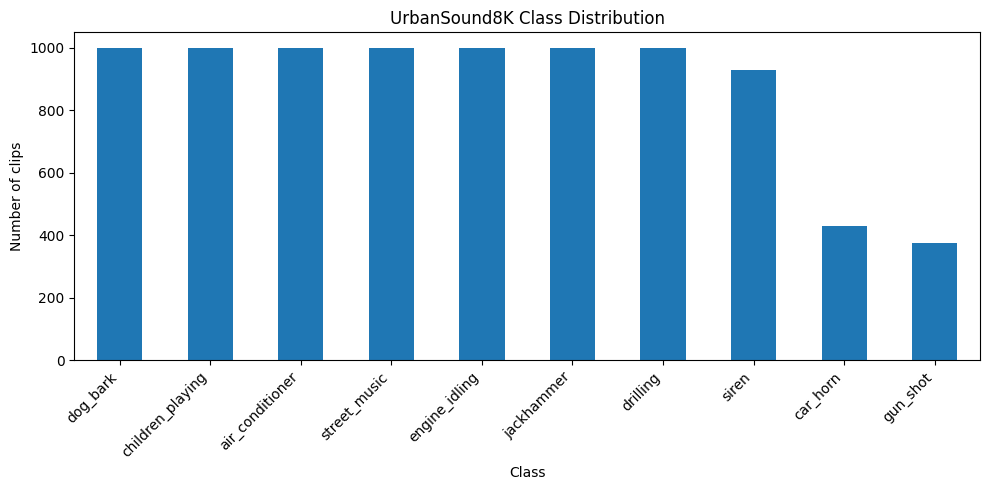

In [6]:
class_counts = metadata["class"].value_counts().sort_values(ascending=False)
display(class_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("UrbanSound8K Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of clips")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Fold Distribution

,count
fold,
4,990
5,936
3,925
2,888
1,873
7,838
10,837
6,823
9,816


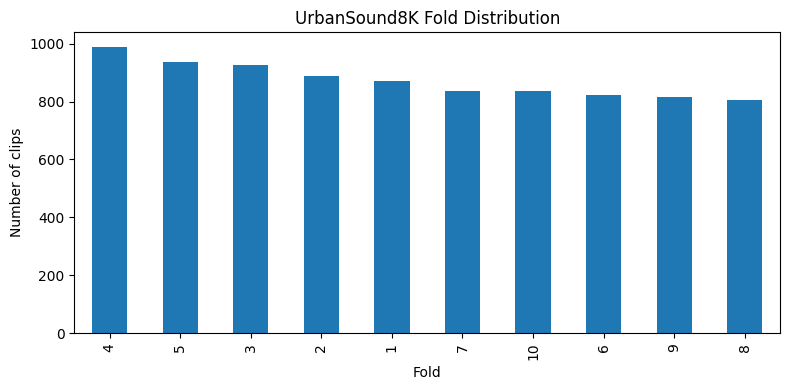

In [7]:
class_counts = metadata["fold"].value_counts().sort_values(ascending=False)
display(class_counts.to_frame("count"))

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("UrbanSound8K Fold Distribution")
plt.xlabel("Fold")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

## Class Distribution per Fold

class,air_conditioner,car_horn,children_playing,dog_bark,drilling,engine_idling,gun_shot,jackhammer,siren,street_music
fold,,,,,,,,,,
1,100,36,100,100,100,96,35,120,86,100
2,100,42,100,100,100,100,35,120,91,100
3,100,43,100,100,100,107,36,120,119,100
4,100,59,100,100,100,107,38,120,166,100
5,100,98,100,100,100,107,40,120,71,100
6,100,28,100,100,100,107,46,68,74,100
7,100,28,100,100,100,106,51,76,77,100
8,100,30,100,100,100,88,30,78,80,100
9,100,32,100,100,100,89,31,82,82,100


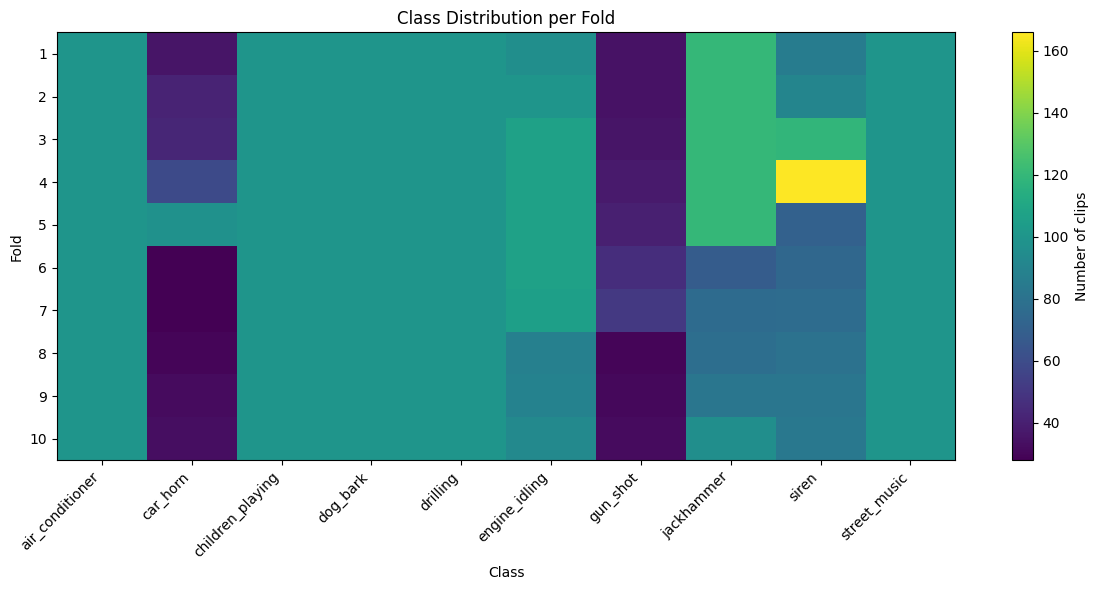

In [8]:
fold_class_table = pd.crosstab(metadata["fold"], metadata["class"])
display(fold_class_table)

plt.figure(figsize=(12, 6))
plt.imshow(fold_class_table.values, aspect="auto")
plt.colorbar(label="Number of clips")
plt.title("Class Distribution per Fold")
plt.xlabel("Class")
plt.ylabel("Fold")
plt.xticks(
    range(len(fold_class_table.columns)),
    fold_class_table.columns,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(fold_class_table.columns)), fold_class_table.index)
plt.tight_layout()
plt.show()

## Audio Duration and Sampling Rate Inspection

In [9]:
import librosa


def inspect_audio_file(path):
    y, sr = librosa.load(path, sr=None, mono=False)
    if y.ndim == 1:
        n_samples = y.shape[0]
        n_channels = 1
    else:
        n_channels = y.shape[0]
        n_samples = y.shape[1]
    duration = n_samples / sr
    return duration, sr, n_channels


samples_df = metadata.sample(min(300, len(metadata)), random_state=10).copy()

durations = []
sample_rates = []
channels = []

for path in tqdm(samples_df["audio_path"], desc="Inspecting audio"):
    duration, sr, n_channels = inspect_audio_file(path)
    durations.append(duration)
    sample_rates.append(sr)
    channels.append(n_channels)

samples_df["duration"] = durations
samples_df["sample_rate"] = sample_rates
samples_df["n_channels"] = channels

display(
    samples_df[
        ["slice_file_name", "class", "fold", "duration", "sample_rate", "n_channels"]
    ].head()
)
display(samples_df[["duration", "sample_rate", "n_channels"]].describe())

Inspecting audio:   0%|          | 0/300 [00:00<?, ?it/s]

Inspecting audio: 100%|██████████| 300/300 [00:03<00:00, 86.19it/s] 


,slice_file_name,class,fold,duration,sample_rate,n_channels
6317,39856-5-0-21.wav,engine_idling,9,4.000000,44100,2
8322,86279-3-0-0.wav,dog_bark,1,3.480000,44100,2
1803,145577-1-0-0.wav,car_horn,2,1.105578,44100,2
775,115240-9-0-16.wav,street_music,8,4.000000,44100,2
6966,59277-0-0-1.wav,air_conditioner,1,4.000000,44100,2


,duration,sample_rate,n_channels
count,300.000000,300.000000,300.000000
mean,3.659184,47564.750000,1.913333
std,0.894092,15799.428237,0.281816
min,0.060000,8000.000000,1.000000
25%,4.000000,44100.000000,2.000000
50%,4.000000,44100.000000,2.000000
75%,4.000000,48000.000000,2.000000
max,4.000000,192000.000000,2.000000


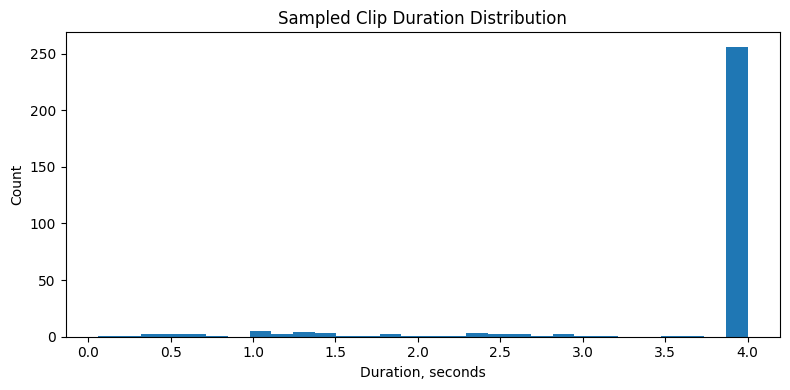

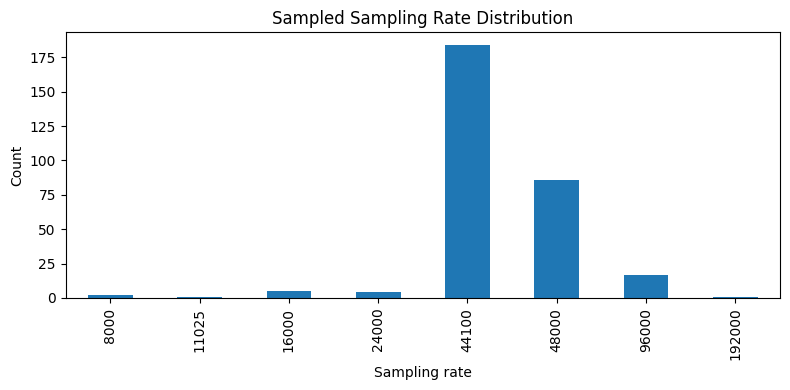

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(samples_df["duration"], bins=30)
plt.title("Sampled Clip Duration Distribution")
plt.xlabel("Duration, seconds")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
samples_df["sample_rate"].value_counts().sort_index().plot(kind="bar")
plt.title("Sampled Sampling Rate Distribution")
plt.xlabel("Sampling rate")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Creating 10-fold cross-validation Plan

In [11]:
cv_plan = []

for test_fold in sorted(metadata["fold"].unique()):
    train_folds = [int(f) for f in sorted(metadata["fold"].unique()) if f != test_fold]
    cv_plan.append(
        {
            "test_fold": int(test_fold),
            "train_folds": train_folds,
            "n_train": int(metadata[metadata["fold"].isin(train_folds)].shape[0]),
            "n_test": int(metadata[metadata["fold"] == test_fold].shape[0]),
        }
    )

cv_plan_df = pd.DataFrame(cv_plan)
display(cv_plan_df)

cv_plan_dir = PROCESSED_DIR / "cv_plan_10fold.json"
with open(cv_plan_dir, "w") as f:
    json.dump(cv_plan, f, indent=2)

print("Saved:", cv_plan_dir)

,test_fold,train_folds,n_train,n_test
0,1,"[2, 3, 4, 5, 6, 7, 8, 9, 10]",7859,873
1,2,"[1, 3, 4, 5, 6, 7, 8, 9, 10]",7844,888
2,3,"[1, 2, 4, 5, 6, 7, 8, 9, 10]",7807,925
3,4,"[1, 2, 3, 5, 6, 7, 8, 9, 10]",7742,990
4,5,"[1, 2, 3, 4, 6, 7, 8, 9, 10]",7796,936
5,6,"[1, 2, 3, 4, 5, 7, 8, 9, 10]",7909,823
6,7,"[1, 2, 3, 4, 5, 6, 8, 9, 10]",7894,838
7,8,"[1, 2, 3, 4, 5, 6, 7, 9, 10]",7926,806
8,9,"[1, 2, 3, 4, 5, 6, 7, 8, 10]",7916,816
9,10,"[1, 2, 3, 4, 5, 6, 7, 8, 9]",7895,837


Saved: D:\Projects\Audio\Audio Pattern Recognition\data\processed\cv_plan_10fold.json


## Saving Cleaned Metadata

In [12]:
metadata_clean = metadata.copy()

preferred_cols = [
    "slice_file_name",
    "fsID",
    "start",
    "end",
    "salience",
    "fold",
    "classID",
    "class",
    "audio_path",
]
existing_cols = [c for c in preferred_cols if c in metadata_clean.columns]
other_cols = [c for c in metadata_clean.columns if c not in existing_cols]
metadata_clean = metadata_clean[existing_cols + other_cols]

metadata_dir = PROCESSED_DIR / "urbansound8k_metadata_clean.csv"
metadata_clean.to_csv(metadata_dir, index=False)

print("Saved", metadata_dir)
metadata_clean.head()

Saved D:\Projects\Audio\Audio Pattern Recognition\data\processed\urbansound8k_metadata_clean.csv


,slice_file_name,fsID,start,end,salience,fold,classID,class,audio_path
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,D:\Projects\Audio\Audio Pattern Recognition\da...
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,D:\Projects\Audio\Audio Pattern Recognition\da...


## Summary for the Report

In [13]:
summary = {
    "n_clips": int(len(metadata_clean)),
    "n_classes": int(metadata_clean["class"].nunique()),
    "classes": sorted(metadata_clean["class"].unique().tolist()),
    "folds": sorted([int(x) for x in metadata_clean["fold"].unique()]),
    "evaluation_protocol": "10-fold cross-validation using the predefined UrbanSound8K folds. In each run, 9 folds are used for training and 1 fold for testing.",
}

summary_path = PROCESSED_DIR / "dataset_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("Saved:", summary_path)

{
  "n_clips": 8732,
  "n_classes": 10,
  "classes": [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music"
  ],
  "folds": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "evaluation_protocol": "10-fold cross-validation using the predefined UrbanSound8K folds. In each run, 9 folds are used for training and 1 fold for testing."
}
Saved: D:\Projects\Audio\Audio Pattern Recognition\data\processed\dataset_summary.json
